# Attention Map Demo

This notebook calls `analysis/plot_attention_map.py` to generate text from a local Hugging Face causal LM, rerun a forward pass with `output_attentions=True`, and plot the attention map from output tokens to input tokens.

Hosted API models usually do not expose attention tensors, so this works best with local/open-weight models such as `Qwen/Qwen3-4B`.

In [ ]:
# Install once if needed:
# %pip install -r analysis/requirements-attention.txt

In [ ]:
from pathlib import Path

analysis_dir = Path("analysis") if Path("analysis/plot_attention_map.py").exists() else Path(".")
script = analysis_dir / "plot_attention_map.py"
model_id = "Qwen/Qwen3-4B"
prompt = "Explain why traffic lights are timed differently at night."
out = analysis_dir / "qwen_output_to_input_attention.png"

In [ ]:
import subprocess
import sys

cmd = [
    sys.executable,
    str(script),
    "--model-id", model_id,
    "--prompt", prompt,
    "--chat",
    "--max-new-tokens", "80",
    "--layer", "-1",
    "--head", "mean",
    "--map", "output_to_input",
    "--out", str(out),
]
subprocess.run(cmd, check=True)

In [ ]:
from IPython.display import Image, display
display(Image(str(out)))

# My code

In [9]:
from pathlib import Path
import sys
from importlib import reload

project_root = Path.cwd()
if not (project_root / "utils").exists():
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import utils.utils as utils
reload(utils)

<module 'utils.utils' from 'h:\\Project\\traffic-hope-network\\utils\\utils.py'>

In [22]:
model_id = "Qwen/Qwen3-4B"
attn_implementation = "eager"
gen_kwargs = {
    'max_new_tokens': 256,
    'temperature': 0.7,
    
}

In [3]:
model, tokenizer = utils.load_model_and_tokenizer(model_id, attn_implementation)

h:\miniconda3\envs\LGM\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading checkpoint shards: 100%|██████████| 3/3 [00:08<00:00,  2.74s/it]
Some parameters are on the meta device because they were offloaded to the cpu and disk.


In [23]:
prompt = r"Natalia sold clips to 48 of her friends in April, and then she sold half as many clips in May. How many clips did Natalia sell altogether in April and May? Given the ground truth answer is $\boxed{72}$"
prompt = utils.build_prompt(tokenizer, "", prompt, False, True)

In [24]:
full_ids, generated_text = utils.generate_and_concate(model, tokenizer, prompt, **gen_kwargs)

In [6]:
generated_text

"<think>\nOkay, let's see. Natalia sold clips to 48 friends in April. Then in May, she sold half as many. So, first, I need to figure out how many she sold in May. Half of 48 is 24, right? Because 48 divided by 2 is 24. Then, to find the total number of clips"

In [7]:
attn_weights, full_outputs = utils.get_attention_weights(model, full_ids)

Prompt length: 70


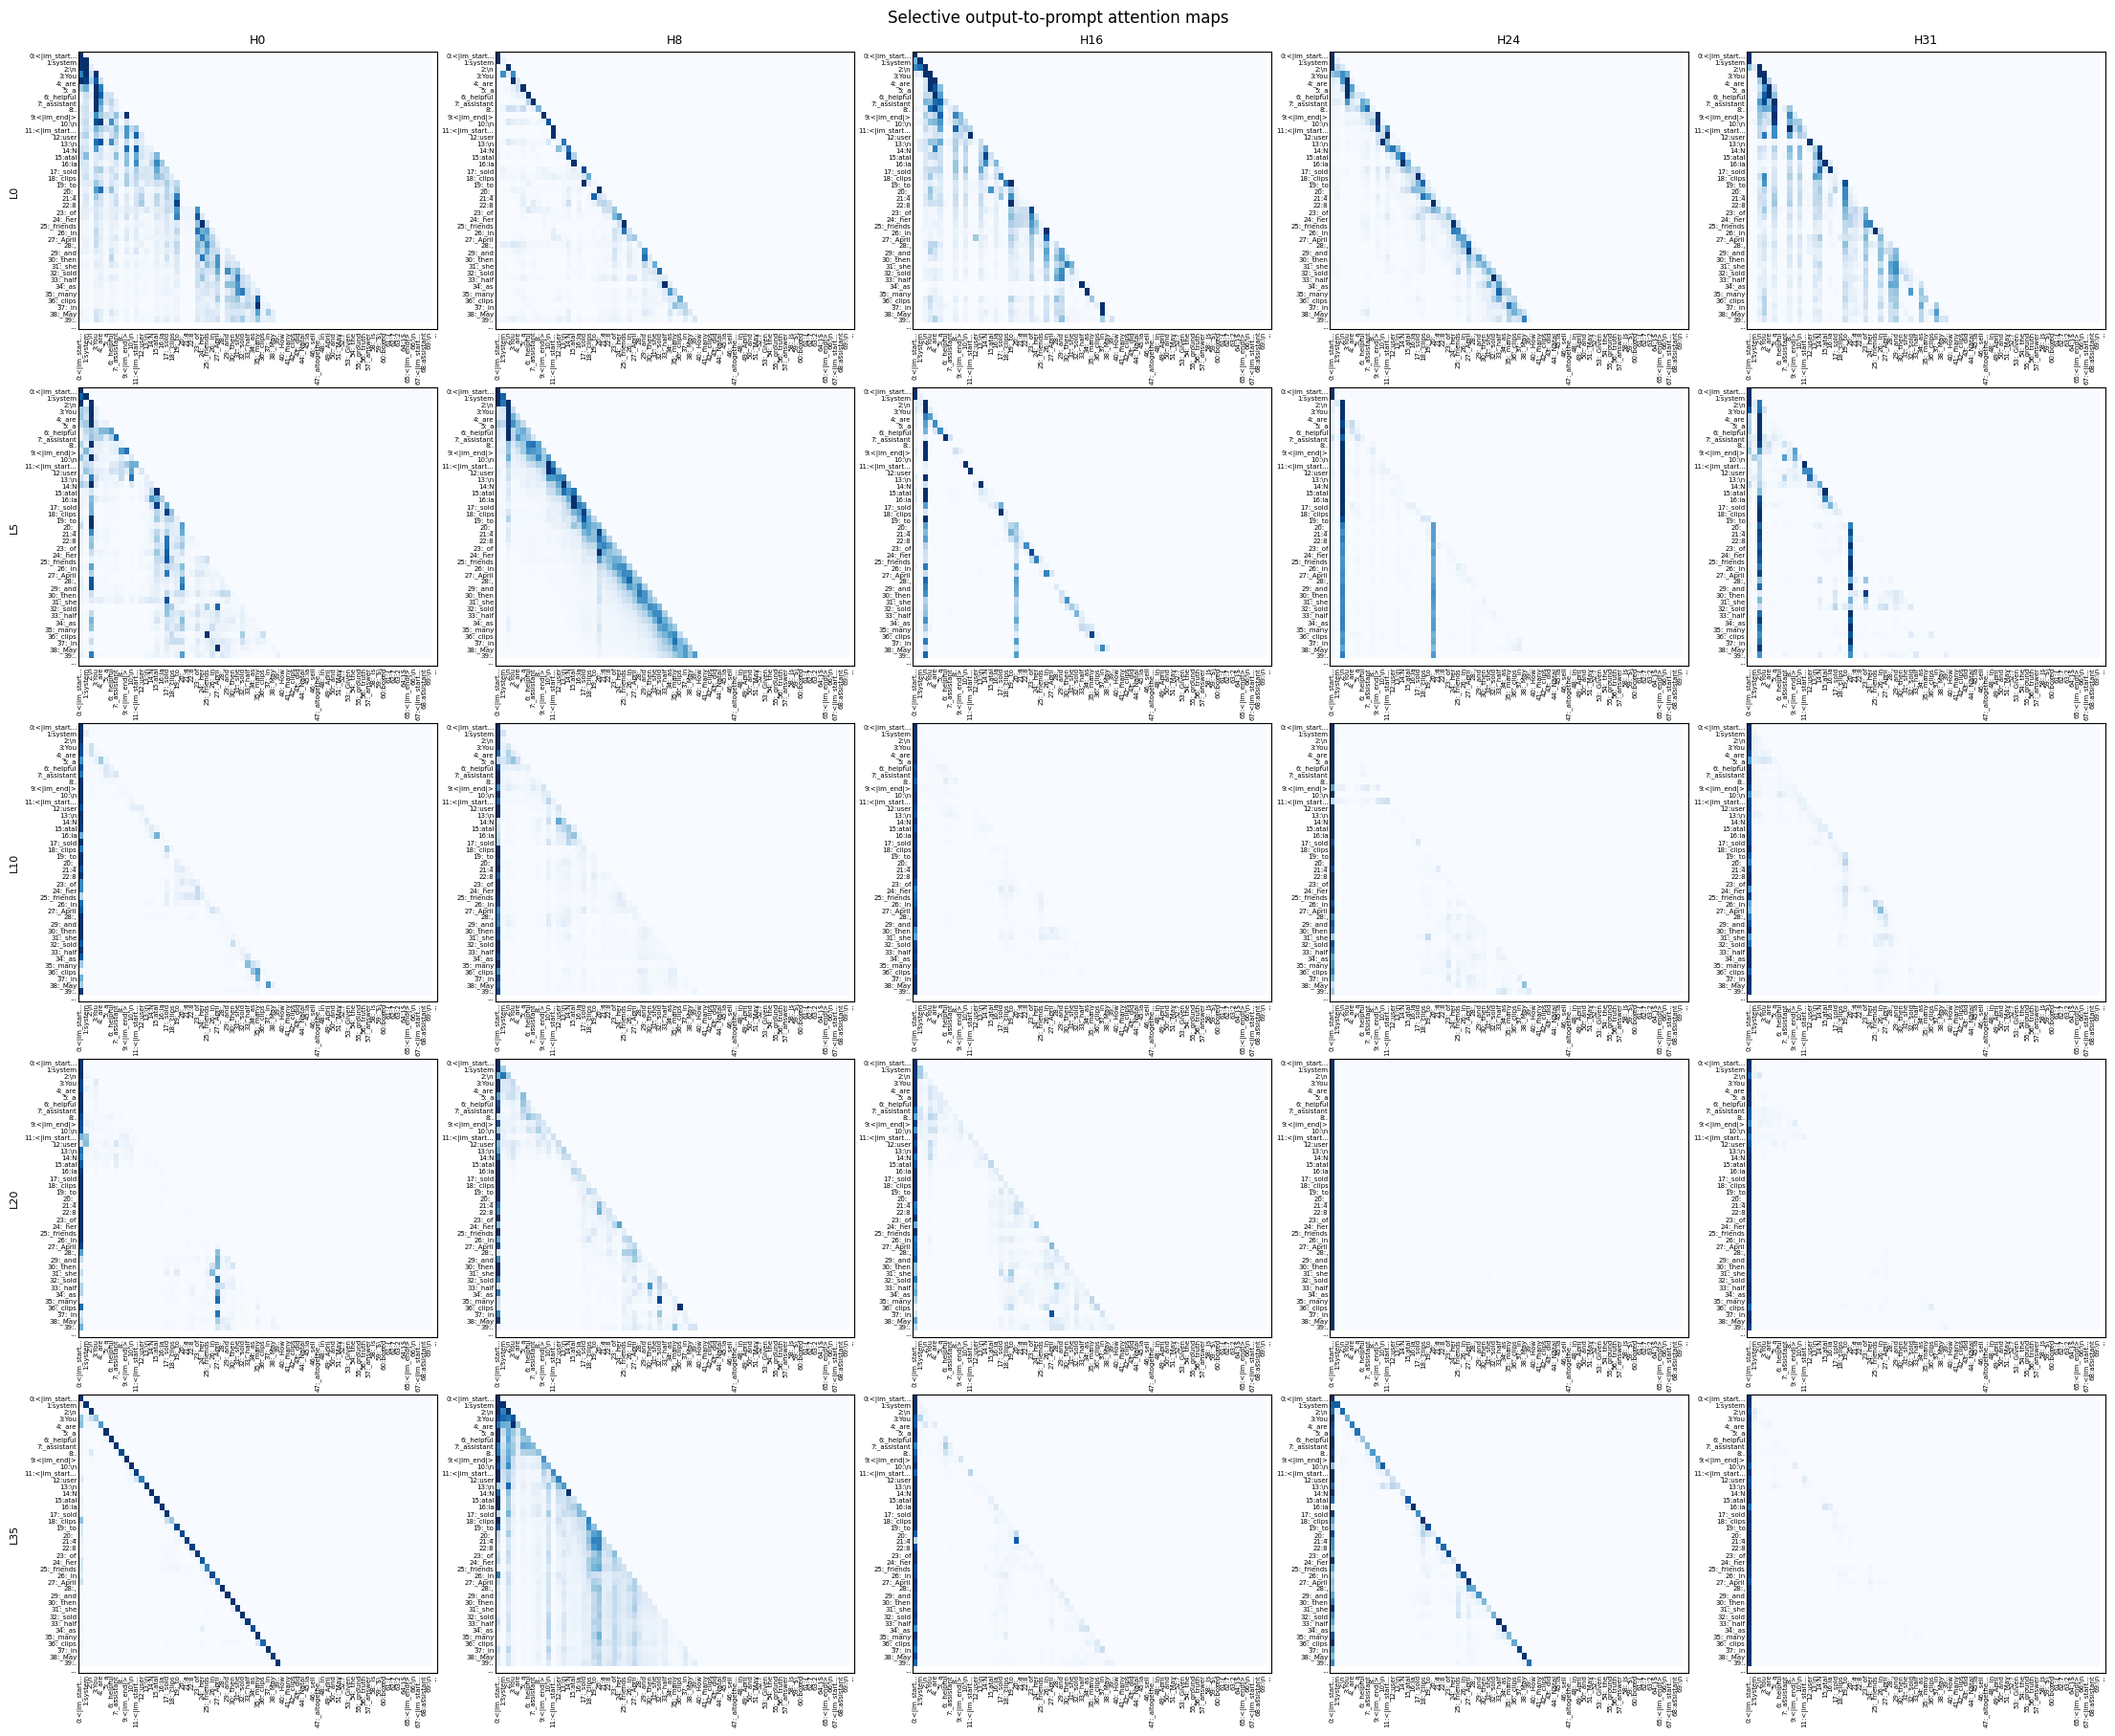

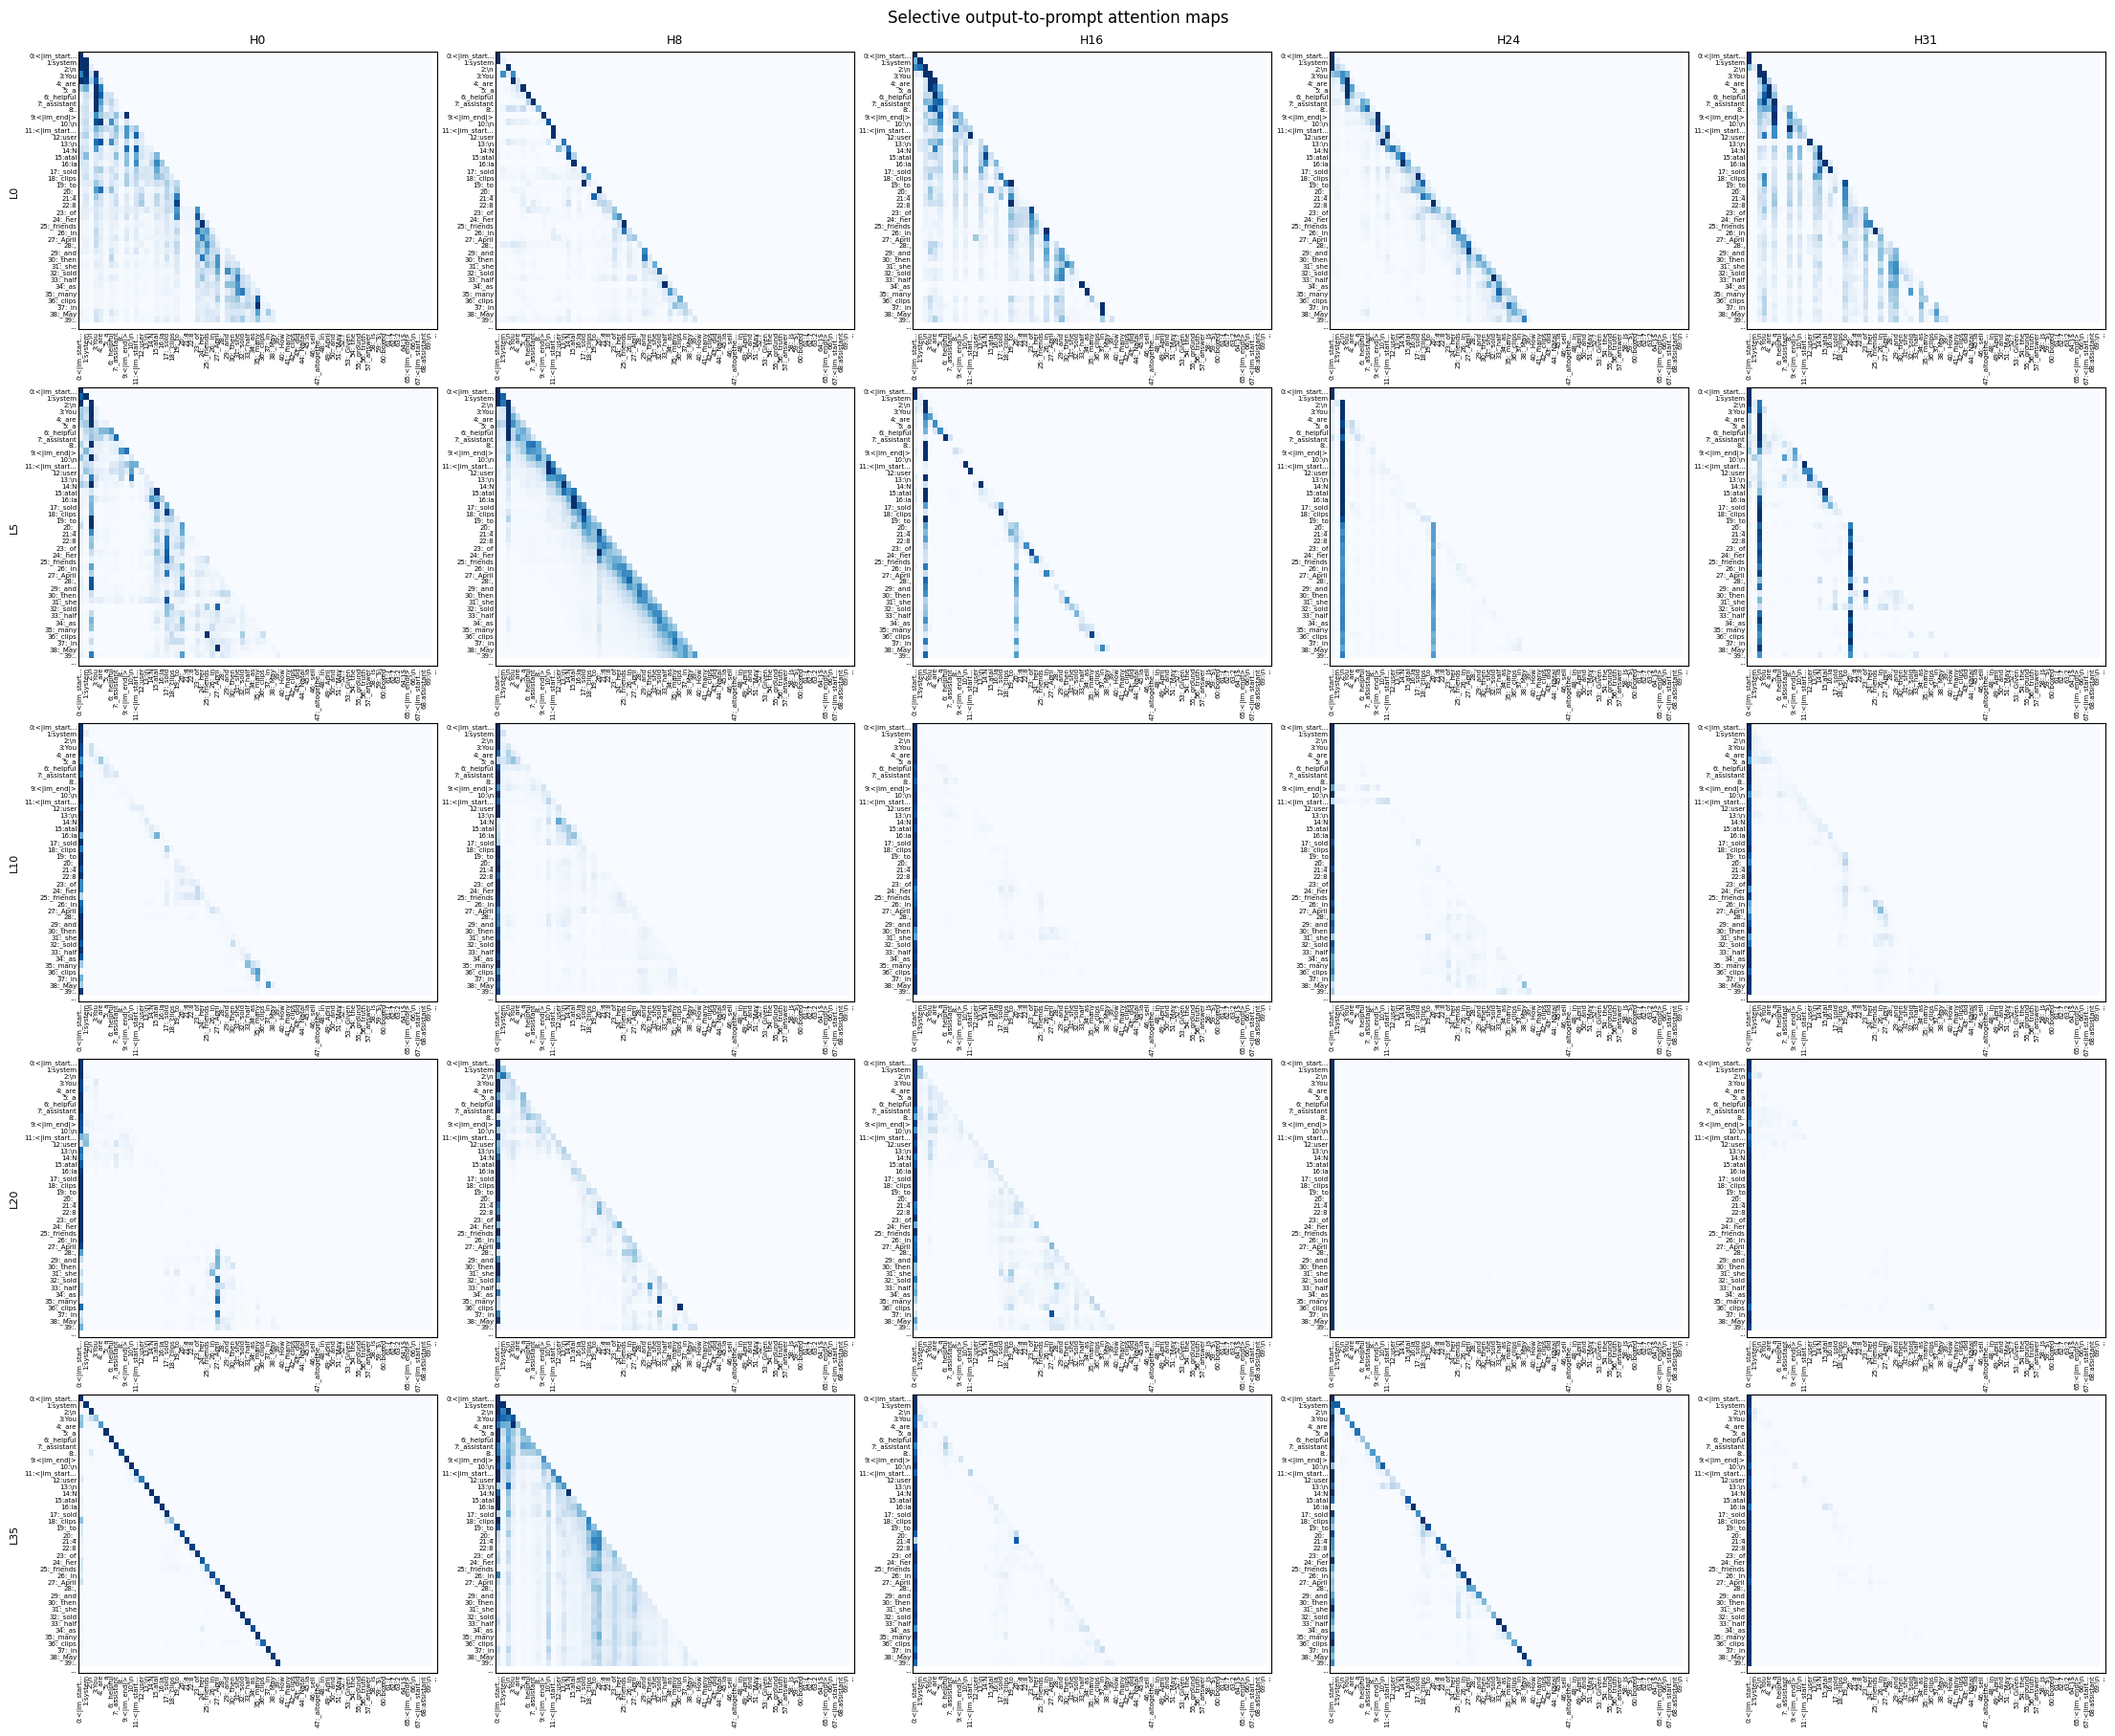

In [21]:
from importlib import reload
reload(utils)

prompt_len = tokenizer(prompt, return_tensors="pt")["input_ids"].shape[1]
print(f"Prompt length: {prompt_len}")
layers = (0, 5, 10, 20, 35)
heads = (0, 8, 16, 24, 31)

fig, axes = utils.plot_selective_attention_map(
    attn_weights,
    layers=layers,
    heads=heads,
    input_range=(None, None),
    output_range=(0, 40),
    prompt_len=prompt_len,
    tokenizer=tokenizer,
    sequence_ids=full_ids,
    out_path=project_root / "analysis" / "selective_attention_maps.png",
    dpi=180,
    figsize=(22, 18),
    label_fontsize=5,
)

fig

In [18]:
generated_text

"<think>\nOkay, let's see. Natalia sold clips to 48 friends in April. Then in May, she sold half as many. So first, I need to figure out how many she sold in May. Half of 48 is 24, right? Because 48 divided by 2 is 24. Then to find the total for both months, I add April and May together. So 48 plus 24 equals 72. That should be the answer. Let me check again. April: 48, May: 48/2=24. Total: 48+24=72. Yeah, that makes sense. The ground truth answer is 72, so that's correct.\n</think>\n\nNatalia sold 48 clips in April. In May, she sold half as many, which is $ \\frac{48}{2} = 24 $ clips. Adding both months together:  \n$$\n48 + 24 = 72\n$$  \n**Answer:** $\\boxed{72}$"

torch.Size([230, 70])

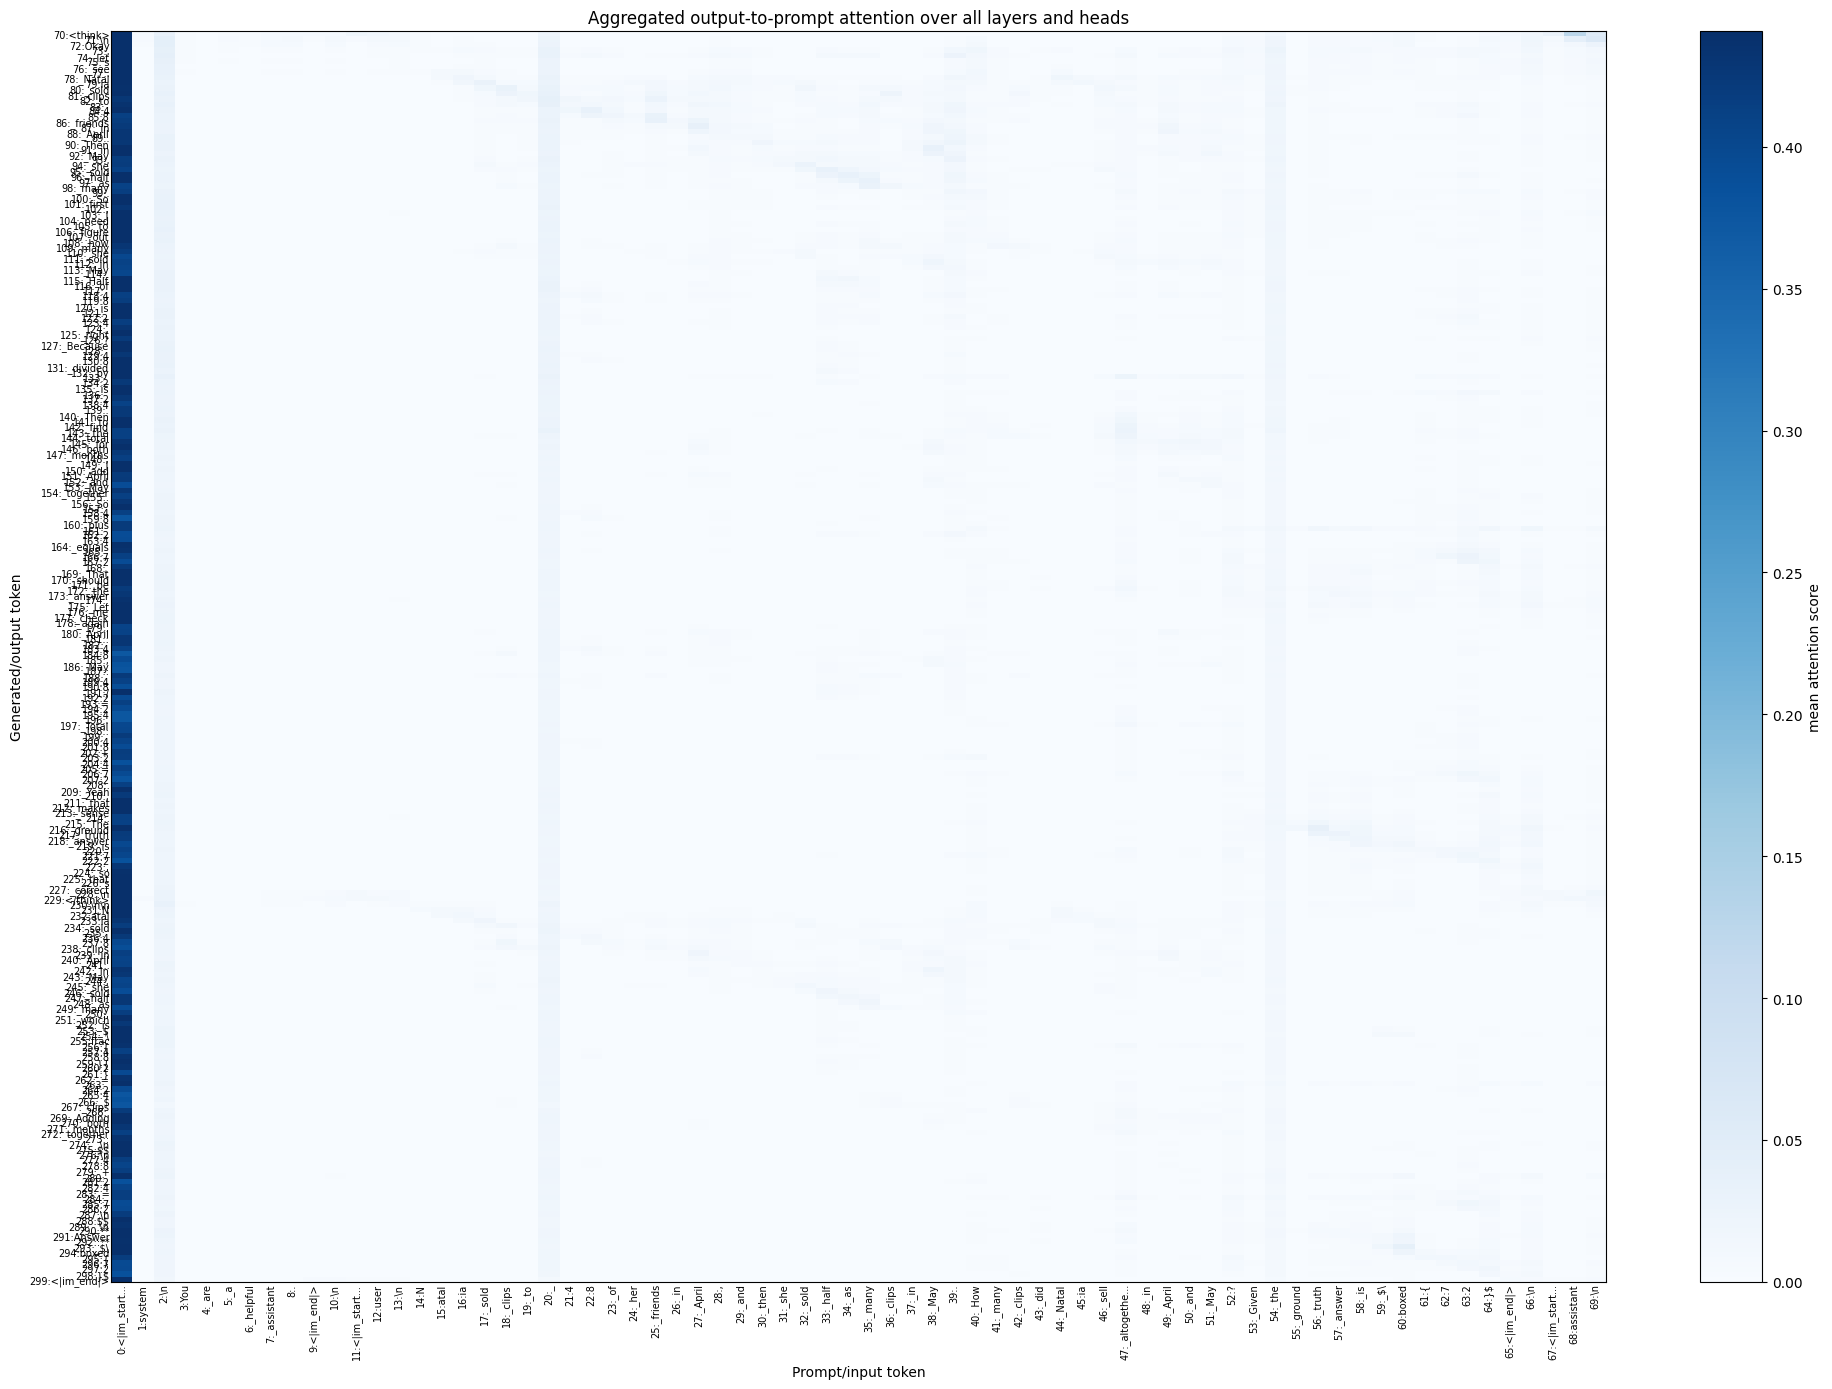

In [20]:
from importlib import reload
reload(utils)

prompt_len = tokenizer(prompt, return_tensors="pt")["input_ids"].shape[1]
agg_attn_map, fig, ax = utils.plot_aggregated_attention(
    attn_weights,
    prompt_len=prompt_len,
    tokenizer=tokenizer,
    sequence_ids=full_ids,
    out_path=project_root / "analysis" / "aggregated_output_to_prompt_attention.png",
    dpi=180,
    figsize=(20, 14),
    label_fontsize=7,
)

agg_attn_map.shape